# Klasifikasi Tipe Akomodasi AirBnB Berdasarkan Karakteristik Listing Menggunakan CNN

# Import Library

In [1]:
pip install streamlit

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Import SMOTE
from imblearn.over_sampling import SMOTE
from collections import Counter

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input, BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

import streamlit as st
import joblib

import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)
tf.random.set_seed(42)

# Load Dataset

In [3]:
import os

local_csv = 'AB_NYC_2019.csv'
if os.path.exists(local_csv):
    df = pd.read_csv(local_csv, low_memory=False)
    print(f"[INFO] Dataset loaded from local file: {df.shape[0]} rows, {df.shape[1]} columns")
else:
    raise FileNotFoundError(
        "Dataset 'AB_NYC_2019.csv' tidak ditemukan di folder project. "
        "Silakan letakkan file CSV di folder project (F:\\Klasifikasi tipe akomodasi) atau ubah nama/jalur file sesuai lokasi Anda."
    )

[INFO] Dataset loaded from local file: 48895 rows, 16 columns


# Filter Kelas

In [4]:
valid_classes = ['Entire home/apt', 'Private room', 'Shared room']
df = df[df['room_type'].isin(valid_classes)]
print(f"Setelah filter kelas: {df.shape}")

Setelah filter kelas: (48895, 16)


# Hapus Duplikat

In [5]:
initial_rows = len(df)
df = df.drop_duplicates()
print(f"Duplikat dihapus: {initial_rows - len(df)} rows")
print(f"Setelah hapus duplikat: {df.shape}")

Duplikat dihapus: 0 rows
Setelah hapus duplikat: (48895, 16)


# Hapus Kolom yang tidak dipakai

In [6]:
columns_to_drop = [
    'id', 'name', 'host_id', 'host_name', 'last_review'
]
columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df = df.drop(columns=columns_to_drop)
print(f"Kolom setelah cleaning: {list(df.columns)}")

Kolom setelah cleaning: ['neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']


# Cleaning Kolom Price

In [7]:
df['price'] = df['price'].astype(str).str.replace(',', '', regex=False)
df['price'] = df['price'].str.replace('$', '', regex=False)
df['price'] = df['price'].str.replace(' ', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Handling Missing Value

In [8]:
print("\n" + "="*70)
print("MISSING VALUE SEBELUM IMPUTASI:")
print(df.isnull().sum())

# Numeric columns - SESUAIKAN DENGAN NAMA KOLOM YANG ADA
numeric_cols = ['price', 'minimum_nights', 'number_of_reviews',
                'reviews_per_month', 'calculated_host_listings_count',
                'availability_365', 'latitude', 'longitude']

# Perbaiki kolom numeric dengan median
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

categorical_cols = ['neighbourhood_group', 'neighbourhood']

for col in categorical_cols:
    if col in df.columns:
        mode_val = df[col].mode()
        if len(mode_val) > 0:
            df[col] = df[col].fillna(mode_val[0])
        else:
            df[col] = df[col].fillna('Unknown')

print("\nMISSING VALUE SETELAH IMPUTASI:")
print(df.isnull().sum())


MISSING VALUE SEBELUM IMPUTASI:
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

MISSING VALUE SETELAH IMPUTASI:
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
dtype: int64


# Perbaiki kolom neighbourhood

In [9]:
if 'neighbourhood group' in df.columns:
    df['neighbourhood group'] = df['neighbourhood group'].replace({
        'manhatan': 'Manhattan',
        'brookln': 'Brooklyn'
    })

# Encoding Fitur Kategorikal

In [10]:
X = df.drop('room_type', axis=1)
y = df['room_type']

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Encoding untuk fitur kategorikal
categorical_features = ['neighbourhood_group', 'neighbourhood']

# Filter yang ada
categorical_features = [col for col in categorical_features if col in X.columns]

X_encoded = pd.get_dummies(X, columns=categorical_features, drop_first=False)
print(f"Jumlah fitur setelah one-hot encoding: {X_encoded.shape[1]}")

Jumlah fitur setelah one-hot encoding: 234


# Normalisasi

In [11]:
from sklearn.preprocessing import StandardScaler

numeric_features = ['price', 'minimum_nights', 'number_of_reviews',
                    'reviews_per_month', 'calculated_host_listings_count',
                    'availability_365', 'latitude', 'longitude']

numeric_features = [col for col in numeric_features if col in X_encoded.columns]

scaler = StandardScaler()
X_encoded[numeric_features] = scaler.fit_transform(X_encoded[numeric_features])
print(f"Fitur numerik dinormalisasi: {numeric_features}")

Fitur numerik dinormalisasi: ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'latitude', 'longitude']


# Feature Selection

In [12]:
print("\n" + "="*70)
print("FEATURE SELECTION")

# Fitur numerik yang tersedia di dataset baru
selected_numeric = ['price', 'minimum_nights', 'number_of_reviews',
                    'reviews_per_month', 'availability_365',
                    'calculated_host_listings_count', 'latitude', 'longitude']

# Filter yang ada
selected_numeric = [col for col in selected_numeric if col in X_encoded.columns]

# Pilih kolom neighbourhood group
group_columns = [col for col in X_encoded.columns if col.startswith('neighbourhood_group_')]

# Pilih kolom neighbourhood (top 20)
neighbourhood_cols = [col for col in X_encoded.columns if col.startswith('neighbourhood_')]
top_neighbourhoods = df['neighbourhood'].value_counts().head(20).index.tolist()
selected_neighbourhood = [f'neighbourhood_{n}' for n in top_neighbourhoods
                          if f'neighbourhood_{n}' in X_encoded.columns]

# Gabungkan fitur
selected_columns = selected_numeric + group_columns + selected_neighbourhood
X_selected = X_encoded[selected_columns].astype(np.float32)

print(f"TOTAL FITUR TERPILIH: {len(selected_columns)} fitur")
print(f" - Numerik: {len(selected_numeric)}")
print(f" - Neighbourhood Group: {len(group_columns)}")
print(f" - Neighbourhood (top 20): {len(selected_neighbourhood)}")


FEATURE SELECTION
TOTAL FITUR TERPILIH: 33 fitur
 - Numerik: 8
 - Neighbourhood Group: 5
 - Neighbourhood (top 20): 20


# Split Data

In [13]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

y_onehot = to_categorical(y_encoded, num_classes=3)

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_onehot,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\nData Training: {X_train.shape[0]} samples ({X_train.shape[0]/len(df)*100:.0f}%)")
print(f"Data Testing:  {X_test.shape[0]} samples ({X_test.shape[0]/len(df)*100:.0f}%)\n")
print("\nDistribusi kelas pada training set:")
for i, kelas in enumerate(label_encoder.classes_):
    count = np.sum(np.argmax(y_train, axis=1) == i)
    print(f"  {kelas}: {count} ({count/len(y_train)*100:.1f}%)")


Data Training: 39116 samples (80%)
Data Testing:  9779 samples (20%)


Distribusi kelas pada training set:
  Entire home/apt: 20327 (52.0%)
  Private room: 17861 (45.7%)
  Shared room: 928 (2.4%)


### Oversampling dengan SMOTE

In [14]:
# Konversi y_train dari one-hot kembali ke label untuk SMOTE
y_train_labels = np.argmax(y_train, axis=1)

print(f"Distribusi kelas sebelum SMOTE: {Counter(y_train_labels)}")

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train_labels)

print(f"Distribusi kelas setelah SMOTE: {Counter(y_train_res)}")

# Konversi y_train_res kembali ke one-hot encoding
y_train_res_onehot = to_categorical(y_train_res, num_classes=3)

# Update X_train dan y_train
X_train = X_train_res
y_train = y_train_res_onehot

print(f"\nShape X_train setelah SMOTE: {X_train.shape}")
print(f"Shape y_train setelah SMOTE: {y_train.shape}")

Distribusi kelas sebelum SMOTE: Counter({np.int64(0): 20327, np.int64(1): 17861, np.int64(2): 928})
Distribusi kelas setelah SMOTE: Counter({np.int64(0): 20327, np.int64(1): 20327, np.int64(2): 20327})

Shape X_train setelah SMOTE: (60981, 33)
Shape y_train setelah SMOTE: (60981, 3)


### Reshape Data untuk CNN

In [15]:
# Reshape data untuk input Conv1D (batch_size, timesteps, features)
# Maka kita reshape dari (samples, features) menjadi (samples, features, 1)
X_train = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Shape X_train setelah reshape: {X_train.shape}")
print(f"Shape X_test setelah reshape: {X_test.shape}")

Shape X_train setelah reshape: (60981, 33, 1)
Shape X_test setelah reshape: (9779, 33, 1)


# Model CNN

In [16]:
from tensorflow.keras.layers import BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input

model = Sequential([
    Input(shape=(X_train.shape[1], 1)), # Input layer (features, 1)

    Conv1D(filters=128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    GlobalAveragePooling1D(),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(len(label_encoder.classes_), activation='softmax')
])

# Kompilasi Model

In [17]:
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Training

In [18]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
953/953 ━━━━━━━━━━━━━━━━━━━━ 34s 26ms/step - accuracy: 0.4968 - loss: 1.0662 - val_accuracy: 0.6867 - val_loss: 0.6965 - learning_rate: 5.0000e-04
Epoch 2/30
953/953 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.6488 - loss: 0.7682 - val_accuracy: 0.7374 - val_loss: 0.6338 - learning_rate: 5.0000e-04
Epoch 3/30
953/953 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.6810 - loss: 0.7115 - val_accuracy: 0.7424 - val_loss: 0.6270 - learning_rate: 5.0000e-04
Epoch 4/30
953/953 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.6983 - loss: 0.6848 - val_accuracy: 0.7729 - val_loss: 0.5933 - learning_rate: 5.0000e-04
Epoch 5/30
953/953 ━━━━━━━━━━━━━━━━━━━━ 24s 25ms/step - accuracy: 0.7074 - loss: 0.6692 - val_accuracy: 0.7512 - val_loss: 0.6104 - learning_rate: 5.0000e-04
Epoch 6/30
953/953 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.7164 - loss: 0.6545 - val_accuracy: 0.7284 - val_loss: 0.6623 - learning_rate: 5.0000e-04
Epoch 7/30
953/953 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/ste

# Evaluasi Model

In [19]:
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

accuracy = accuracy_score(y_true, y_pred)
print(f"\nAkurasi Model: {accuracy*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

306/306 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Akurasi Model: 79.55%

Classification Report:
                 precision    recall  f1-score   support

Entire home/apt       0.87      0.87      0.87      5082
   Private room       0.83      0.72      0.77      4465
    Shared room       0.19      0.68      0.30       232

       accuracy                           0.80      9779
      macro avg       0.63      0.75      0.64      9779
   weighted avg       0.83      0.80      0.81      9779


Confusion Matrix:
[[4410  604   68]
 [ 649 3212  604]
 [  23   52  157]]


# Visualisasi Akhir

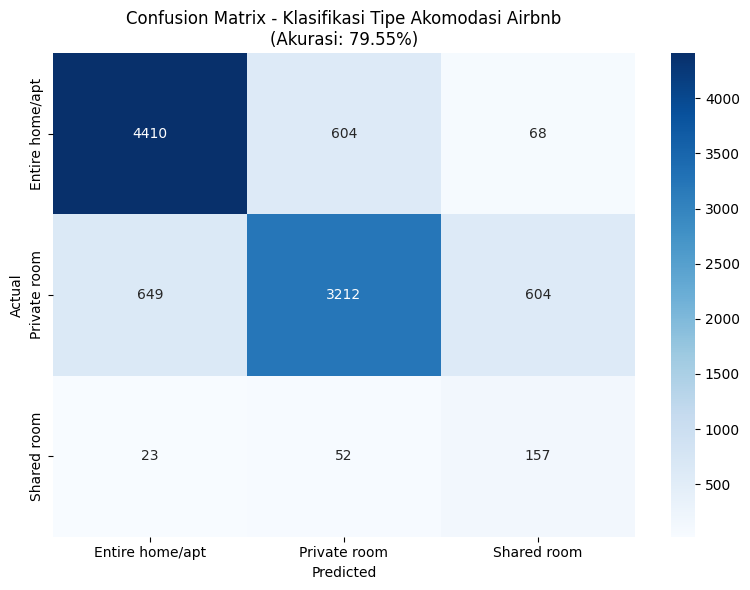

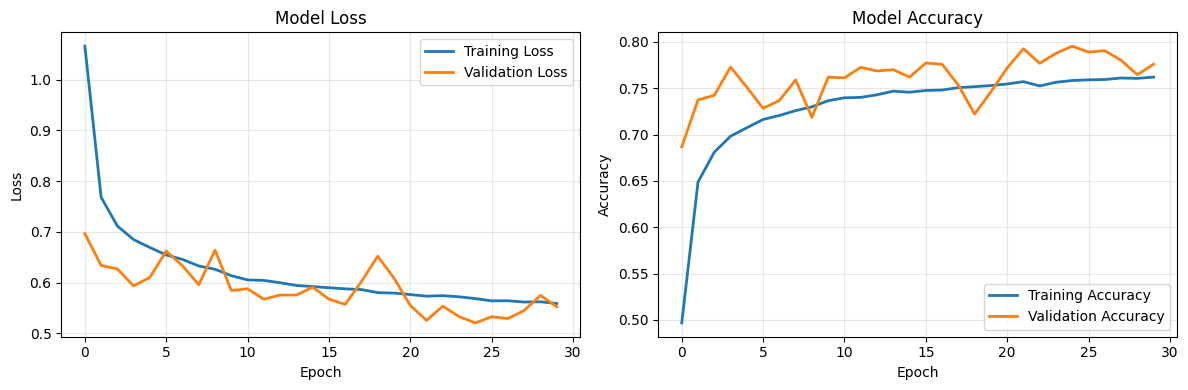

In [20]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title(f'Confusion Matrix - Klasifikasi Tipe Akomodasi Airbnb\n(Akurasi: {accuracy*100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Training History Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

# Simpan Model

In [21]:
import joblib

# Simpan model dan preprocessor
model.save('cnn_airbnb_model.h5')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(label_encoder, 'label_encoder_cnn.pkl')
joblib.dump(X_encoded.columns.tolist(), 'feature_columns.pkl')

print("Model dan preprocessor disimpan!")

Model dan preprocessor disimpan!
